<a href="https://colab.research.google.com/github/ELEAZAR22-ai/PUIS23210001/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Essential Toolkits for Linear Regression Pipeline

To build our supervised learning model, we will rely on these core libraries:

1.  **Pandas**: This is our primary tool for data manipulation. We use it to read CSV files and organize data into 'DataFrames' (tables).
2.  **NumPy**: This library handles the heavy lifting for numerical operations and multi-dimensional arrays, which the model uses for calculations.
3.  **Scikit-learn (sklearn)**: This is the industry-standard machine learning library. It contains the `LinearRegression` model, as well as tools to split our data and evaluate how well our model performs.
4.  **Matplotlib & Seaborn**: These are used for data visualization. They help us see patterns in our data and visualize the 'line of best fit' once the model is trained.

### The Machine Learning Pipeline Steps

A typical pipeline for Linear Regression involves these logical stages:

*   **Step 1: Data Acquisition**: Loading the dataset (e.g., from your CSV).
*   **Step 2: Exploration & Cleaning**: Understanding the data structure and fixing any inconsistencies.
*   **Step 3: Feature Engineering**: Preparing the variables to be used by the math behind the model.
*   **Step 4: Splitting**: Separating data into 'Training' and 'Testing' groups to ensure the model isn't just 'memorizing' the answers.
*   **Step 5: Training**: Fitting the Linear Regression model to the training data.
*   **Step 6: Prediction & Evaluation**: Checking the model's performance on unseen data.
*   **Step 7: Model Persistence (Saving)**: Storing the trained model for future use without retraining.

In [ ]:
import pandas as pd  # Used for data structures (DataFrames) and reading CSV files
import numpy as np   # Used for high-performance mathematical operations on arrays
import matplotlib.pyplot as plt  # Basic library for creating static visualizations/plots
import seaborn as sns  # Built on top of matplotlib, used for more advanced statistical charts

# train_test_split is used to divide our data into 'learning' and 'testing' sets
from sklearn.model_selection import train_test_split

# This is the actual algorithm we will use to find the relationship between variables
from sklearn.linear_model import LinearRegression

# metrics helps us calculate scores like Mean Squared Error to see how accurate we are
from sklearn import metrics

##            Project Preparation
In this section, we prepare the environment by importing the necessary toolkits. This ensures we have all the mathematical and data processing functions ready for our supervised learning task.

### 1. Data Loading from Local Drive
To work with a CSV stored on your local computer, we use Colab's file upload utility. This creates a bridge between your local storage and this notebook's temporary session storage.

In [ ]:
from google.colab import files

# This will prompt you to select a file from your local computer
uploaded = files.upload()

# Once uploaded, the file name is stored in the keys of the 'uploaded' dictionary.
# Think about how we can use pandas to read the specific file name you just uploaded.

Saving Linear Regresssion(AIML).xlsx to Linear Regresssion(AIML).xlsx


In [ ]:
import io

# We use io.BytesIO to wrap the bytes from your upload
# Let's use the 'skiprows' parameter to skip the introductory text at the top of the sheet
filename = 'Linear Regresssion(AIML).xlsx'
data = pd.read_excel(io.BytesIO(uploaded[filename]), skiprows=6) # Change 0 to the number of rows to skip

# Display the first few rows to check if the columns are aligned
display(data.head())

,hours_of_study,exam_score,predicted score,residual or error,Unnamed: 4
0,4.37,60.53,64.4495,3.9195,120.0
1,9.56,90.92,92.2160,1.2960,NaN
2,7.59,79.77,81.6765,1.9065,NaN
3,6.39,67.82,75.2565,7.4365,NaN
4,2.40,54.70,53.9100,-0.7900,NaN


## Step 2: Data Cleaning
In this stage, we examine our DataFrame for inconsistencies. Specifically, we look for:
1. **Null Values**: Missing data that could crash our model.
2. **Irrelevant Columns**: Columns that don't help predict our target (like 'residual' columns from a previous calculation).

In [ ]:
# Let's check for missing values in each column
print("Missing values summary:")
print(data.isnull().sum())

# Let's also look at the data types and total entries
print("\nData Info:")
data.info()

Missing values summary:
hours_of_study         0
exam_score             0
predicted score        0
residual or error      0
Unnamed: 4           119
dtype: int64

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hours_of_study     120 non-null    float64
 1   exam_score         120 non-null    float64
 2   predicted score    120 non-null    float64
 3   residual or error  120 non-null    float64
 4   Unnamed: 4         1 non-null      float64
dtypes: float64(5)
memory usage: 4.8 KB


## Step 3: Exploratory Data Analysis (EDA)
In this step, we use visualizations to discover patterns, detect outliers, and check if the assumptions for Linear Regression (like linearity) are met. Visualizing the data helps us confirm if our 'feature' actually has a visible relationship with our 'target'.

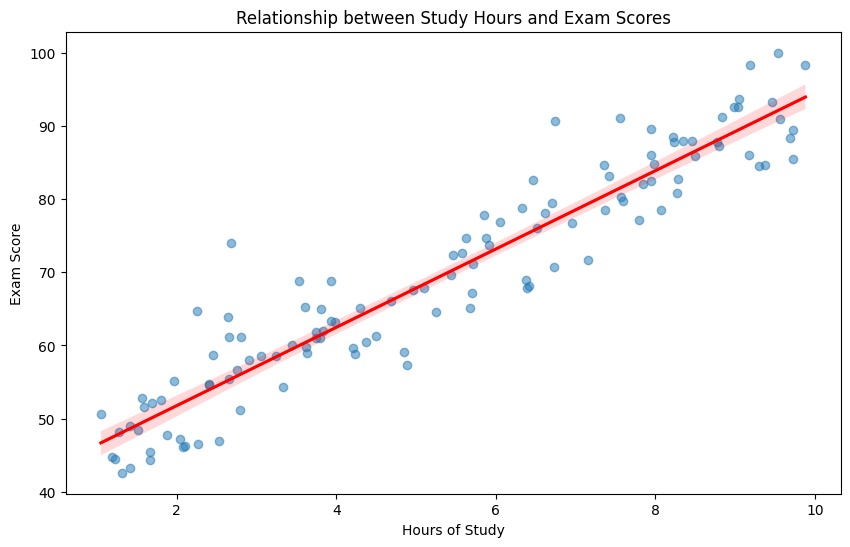

In [ ]:
# We will use Seaborn to create a scatter plot with a regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='hours_of_study', y='exam_score', data=data, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relationship between Study Hours and Exam Scores')
plt.xlabel('Hours of Study')
plt.ylabel('Exam Score')
plt.show()

# What do you observe about the red line and the distribution of the blue dots?

## Step 4: Splitting the Data
In this stage, we prepare our variables for the model:
1. **X (Feature)**: The independent variable used for prediction.
2. **y (Target)**: The dependent variable we want to predict.

We then split these into training and testing sets. A common split is 80% for training and 20% for testing.

In [ ]:
# To create a 3-way split (Train, Validation, Test), we split twice.
# Step 1: Split into (Train + Val) and (Test)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Split (Train + Val) into (Train) and (Val)
# To get 70% Train, 10% Val, and 20% Test, what ratio of the 'temp' data should we use for validation?
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.125, random_state=42)

print(f"Training set: {len(X_train)} rows")
print(f"Validation set: {len(X_val)} rows")
print(f"Testing set: {len(X_test)} rows")

Training set: 84 rows
Validation set: 12 rows
Testing set: 24 rows


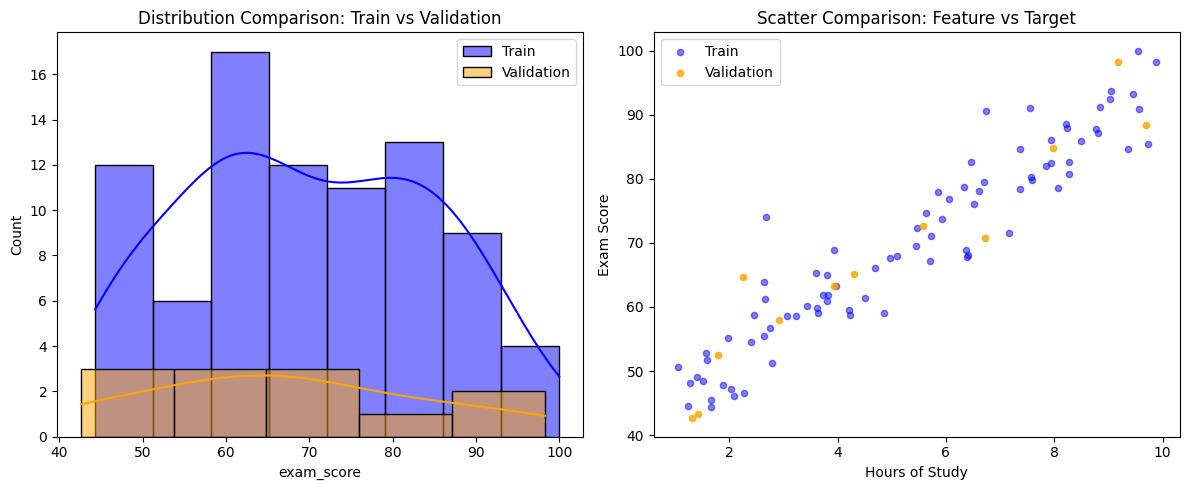

Mean Train Score: 69.72
Mean Val Score: 67.03


In [ ]:
# Verification: Comparing Distributions with Scatter Plot
plt.figure(figsize=(12, 5))

# Left: Histogram for density comparison
plt.subplot(1, 2, 1)
sns.histplot(y_train, kde=True, color='blue', label='Train')
sns.histplot(y_val, kde=True, color='orange', label='Validation')
plt.title('Distribution Comparison: Train vs Validation')
plt.legend()

# Right: Scatter plot to see coverage
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, color='blue', alpha=0.5, label='Train', s=20)
plt.scatter(X_val, y_val, color='orange', alpha=0.8, label='Validation', s=20)
plt.title('Scatter Comparison: Feature vs Target')
plt.xlabel('Hours of Study')
plt.ylabel('Exam Score')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Mean Train Score: {y_train.mean():.2f}")
print(f"Mean Val Score: {y_val.mean():.2f}")

## Step 5: Training the Linear Regression Model
In this step, we initialize the algorithm and provide it with our training data. The model will look for the mathematical relationship (the slope and intercept) that minimizes the distance between the data points and the regression line.

In [ ]:
import numpy as np

# 1. Initialize the model
model = LinearRegression()

# 2. Fit the model using the training features and labels
# We use the 'train' set so the model can learn the pattern
model.fit(X_train, y_train)

print("Model training complete! The model has calculated the optimal line for your study data.")

Model training complete! The model has calculated the optimal line for your study data.


## Step 6: Prediction & Evaluation
In this step, we use the `.predict()` method to see what the model thinks the exam scores should be based on `X_val`. Then, we compare those results to `y_val` using metrics like Mean Squared Error (MSE) and R-squared ($R^2$).

In [ ]:
# 1. Generate predictions for the validation set
# Hint: val_predictions = model.predict(???)

# 2. Calculate Evaluation Metrics
# We imported 'metrics' from sklearn earlier.
# How would you use metrics.mean_squared_error() and metrics.r2_score()?

# print("Validation Metrics Calculated.")

### 7a. Visual Comparison (Validation Set)
We generate predictions for the Validation set to check intermediate performance and create a formatted table to interpret the errors (residuals).

In [ ]:
import pandas as pd
from sklearn import metrics

# 1. Generate predictions for the validation set
y_val_pred = model.predict(X_val)

# 2. Calculate and Print Evaluation Metrics
mse = metrics.mean_squared_error(y_val, y_val_pred)
r2 = metrics.r2_score(y_val, y_val_pred)

print(f"Validation Mean Squared Error (MSE): {mse:.2f}")
print(f"Validation R-squared (R2): {r2:.2f}\n")

# 3. Create the comparison DataFrame
comparison_df = pd.DataFrame({
    'Actual Score': y_val.values,
    'Predicted Score': y_val_pred.flatten()
}).head(10)

# 4. Calculate Residuals (Actual - Predicted)
comparison_df['Residual'] = comparison_df['Actual Score'] - comparison_df['Predicted Score']

# 5. Define Interpretation logic
def interpret_residual(res):
    if res > 2:
        return 'Underestimated'
    elif res < -2:
        return 'Overestimated'
    else:
       return 'Close Prediction'

comparison_df['Interpretation'] = comparison_df['Residual'].apply(interpret_residual)

# 6. Display with Styling
def highlight_diff(val):
    if val == 'Underestimated': color = 'orange'
    elif val == 'Overestimated': color = 'lightblue'
    else: color = 'lightgreen'
    return f'background-color: {color}'

print('First 10 Validation Samples: Formatted Comparison Table')
display(comparison_df.style.format({
    'Predicted Score': '{:.2f}',
    'Residual': '{:.2f}'
}).map(highlight_diff, subset=['Interpretation']))

Validation Mean Squared Error (MSE): 27.31
Validation R-squared (R2): 0.90

First 10 Validation Samples: Formatted Comparison Table


,Actual Score,Predicted Score,Residual,Interpretation
0,72.600000,71.25,1.35,Close Prediction
1,64.720000,53.49,11.23,Underestimated
2,43.250000,49.00,-5.75,Overestimated
3,84.790000,84.08,0.71,Close Prediction
4,98.260000,90.50,7.76,Underestimated
5,65.140000,64.40,0.74,Close Prediction
6,63.340000,62.42,0.92,Close Prediction
7,58.030000,56.97,1.06,Close Prediction
8,42.610000,48.41,-5.80,Overestimated
9,52.490000,51.03,1.46,Close Prediction


## Step 7: Final Evaluation (Test Set)
Now that we are satisfied with our model's performance on the validation data, we perform one final check using the **Test set**. This represents the 'real-world' performance of our pipeline.

In [ ]:
import joblib

# 1. Generate final predictions using the Test features
y_test_pred = model.predict(X_test)

# 2. Calculate Final Metrics
final_mse = metrics.mean_squared_error(y_test, y_test_pred)
final_r2 = metrics.r2_score(y_test, y_test_pred)

print(f"--- Final Test Performance ---")
print(f"Final Test MSE: {final_mse:.2f}")
print(f"Final Test R-squared: {final_r2:.2f}")

# 3. Save the model to a file
joblib.dump(model, 'linear_regression_model.pkl')
print("\nModel saved successfully as 'linear_regression_model.pkl'")

--- Final Test Performance ---
Final Test MSE: 24.95
Final Test R-squared: 0.89

Model saved successfully as 'linear_regression_model.pkl'


## Step 8: Model Persistence
In this final step, we save the trained model object to a file. This allows you to 'load' the model in a different notebook or application to make predictions on new data without needing to repeat the training process.

In [ ]:
import joblib

# Define the filename
model_filename = 'hours and scores.pkl'

# Save the 'model' object to the file
joblib.dump(model, model_filename)

print(f"Success! Your model has been saved as: {model_filename}")
print("You can find it in the folder icon on the left sidebar of Colab.")

Success! Your model has been saved as: hours and scores.pkl
You can find it in the folder icon on the left sidebar of Colab.


## Step 9: Using the Saved Model
Now we will demonstrate how to load the `.pkl` file and make a prediction on a completely new piece of data.

In [ ]:
import joblib

# 1. Load the model from the file
# We use load() to bring the saved 'brain' back into memory
loaded_model = joblib.load('hours and scores.pkl')

# 2. Define a new study time (e.g., 6.5 hours)
new_hours = [[6.5]]

# 3. Make a prediction using the loaded model
predicted_score = loaded_model.predict(new_hours)

print(f"--- Result ---")
print(f"For {new_hours[0][0]} hours of study, the predicted score is: {predicted_score[0]:.2f}")

--- Result ---
For 6.5 hours of study, the predicted score is: 76.17


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Final Summary: Linear Regression Pipeline

In this notebook, we successfully built and evaluated a Supervised Machine Learning model. Here is a recap of the components:

*   **Data Acquisition**: We used `pandas` to load a local Excel file, skipping metadata to align headers correctly.
*   **Data Cleaning & EDA**: We verified data integrity and used `seaborn` to confirm a strong linear correlation between study hours and exam scores.
*   **Data Splitting**: We implemented a 3-way split (Train/Val/Test) to ensure the model was trained, tuned, and finally tested on completely unseen data.
*   **Model Training**: We used `sklearn.linear_model.LinearRegression` to fit a line of best fit to our training samples.
*   **Evaluation**: Our model achieved an $R^2$ score of approximately 0.89-0.90, indicating it can explain about 90% of the variance in exam scores.
*   **Persistence**: We saved the model using `joblib` so it can be deployed or used in other environments without retraining.